In [1]:
import pandas as pd
import glob
import os
import bramlib

In [10]:
def create_df(file, label=None):
    df = pd.read_csv(file)
    user_id = os.path.basename(file).split(".")[0]
    user_id = int(user_id[1:])
    df["user_id"] = user_id

    if label:
        df.columns = [f"{label}_{col}" if col not in ["timestamp", "user_id"] else col for col in df.columns]
    return df

def combine_folder(folder, limit=-1):
    all_files = glob.glob(os.path.join(folder, "*.csv"))
    df_list = []
    
    n = 0
    for file in all_files[:limit]:
        df = create_df(file=file)
        df_list.append(df)

        n += 1
        if n % 100 == 0:
            print(f"Currently on:{n}")

    combined_df = pd.concat(df_list, ignore_index=True)
    return combined_df

def get_other_folders(folders, main_df):

    for folder in folders:
        folder_label = os.path.basename(os.path.normcase(folder)).lower()
        print(f"currently on: {folder_label}")
        
        extra_dfs = []        
        files = glob.glob(os.path.join(folder, "*.csv"))
        valid_users = main_df["user_id"].unique()

        for file in files:
            userc = os.path.basename(file).split(".")[0]
            userc_id = int(userc[1:])

            if userc_id in valid_users:
                df_extra = create_df(file, label=folder_label)
                extra_dfs.append(df_extra)
        
        if extra_dfs:
            temp_df = pd.concat(extra_dfs, ignore_index=True)
            main_df = pd.merge(main_df, temp_df, on=["user_id", "timestamp"], how="outer")

            common = set(main_df["timestamp"]).intersection(set(temp_df["timestamp"]))
            print(len(common))
    return main_df


In [4]:
df = combine_folder(r"C:\Users\bramm\student-grade data\Data\raw\EdNet-KT1\KT1", 1000)
df.head(10)

Currently on:100
Currently on:200
Currently on:300
Currently on:400
Currently on:500
Currently on:600
Currently on:700
Currently on:800
Currently on:900
Currently on:1000


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,1565096190868,1,q5012,b,38000,1
1,1565096221062,2,q4706,c,24000,1
2,1565096293432,3,q4366,b,68000,1
3,1565096339668,4,q4829,a,42000,1
4,1565096401774,5,q6528,b,59000,1
5,1565096463370,6,q4793,a,58000,1
6,1565096501746,7,q6488,a,35000,1
7,1565097101361,8,q356,b,23000,1
8,1565097171393,9,q1382,c,22000,1
9,1565097240758,10,q830,b,25000,1


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 260019 entries, 0 to 260018
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   timestamp     260019 non-null  int64
 1   solving_id    260019 non-null  int64
 2   question_id   260019 non-null  str  
 3   user_answer   260008 non-null  str  
 4   elapsed_time  260019 non-null  int64
 5   user_id       260019 non-null  int64
dtypes: int64(4), str(2)
memory usage: 13.4 MB


In [6]:
df.describe()

,timestamp,solving_id,elapsed_time,user_id
count,2.600190e+05,260019.000000,2.600190e+05,260019.000000
mean,1.540503e+12,942.433880,2.636158e+04,61769.245171
std,2.169905e+10,1169.244105,5.283649e+04,45095.081979
min,1.510481e+12,1.000000,0.000000e+00,1.000000
25%,1.518054e+12,152.000000,1.533300e+04,10052.000000
50%,1.536068e+12,522.000000,2.000000e+04,100107.000000
75%,1.564442e+12,1309.000000,2.925000e+04,100581.000000
max,1.575280e+12,7772.000000,1.349900e+07,100901.000000


In [11]:
folders = [
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT2\\KT2",
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT3\\KT3",
    r"C:\\Users\\bramm\\student-grade data\\Data\\raw\\EdNet-KT4\\KT4"    
]
df = get_other_folders(folders, df)
df.head(10)

currently on: kt2
70320
currently on: kt3
117012
currently on: kt4
149556


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id,kt2_action_type_x,kt2_item_id_x,kt2_source_x,kt2_user_answer_x,...,kt3_item_id_y,kt3_source_y,kt3_user_answer_y,kt3_platform_y,kt4_action_type_y,kt4_item_id_y,kt4_cursor_time_y,kt4_source_y,kt4_user_answer_y,kt4_platform_y
0,1565096151269,NaN,NaN,NaN,NaN,1,enter,b3544,diagnosis,NaN,...,b3544,diagnosis,NaN,mobile,enter,b3544,NaN,diagnosis,NaN,mobile
1,1565096187972,NaN,NaN,NaN,NaN,1,respond,q5012,diagnosis,b,...,q5012,diagnosis,b,mobile,respond,q5012,NaN,diagnosis,b,mobile
2,1565096190868,1.0,q5012,b,38000.0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1565096194904,NaN,NaN,NaN,NaN,1,submit,b3544,diagnosis,NaN,...,b3544,diagnosis,NaN,mobile,submit,b3544,NaN,diagnosis,NaN,mobile
4,1565096195001,NaN,NaN,NaN,NaN,1,enter,b3238,diagnosis,NaN,...,b3238,diagnosis,NaN,mobile,enter,b3238,NaN,diagnosis,NaN,mobile
5,1565096218682,NaN,NaN,NaN,NaN,1,respond,q4706,diagnosis,c,...,q4706,diagnosis,c,mobile,respond,q4706,NaN,diagnosis,c,mobile
6,1565096221062,2.0,q4706,c,24000.0,1,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1565096223029,NaN,NaN,NaN,NaN,1,submit,b3238,diagnosis,NaN,...,b3238,diagnosis,NaN,mobile,submit,b3238,NaN,diagnosis,NaN,mobile
8,1565096223119,NaN,NaN,NaN,NaN,1,enter,b2898,diagnosis,NaN,...,b2898,diagnosis,NaN,mobile,enter,b2898,NaN,diagnosis,NaN,mobile
9,1565096290094,NaN,NaN,NaN,NaN,1,respond,q4366,diagnosis,b,...,q4366,diagnosis,b,mobile,respond,q4366,NaN,diagnosis,b,mobile


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 412847 entries, 0 to 412846
Data columns (total 22 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   timestamp        412847 non-null  int64  
 1   solving_id       260019 non-null  float64
 2   question_id      260019 non-null  str    
 3   user_answer      260008 non-null  str    
 4   elapsed_time     260019 non-null  float64
 5   user_id          412847 non-null  int64  
 6   kt2_action_type  71673 non-null   str    
 7   kt2_item_id      71673 non-null   str    
 8   kt2_source       71673 non-null   str    
 9   kt2_user_answer  28149 non-null   str    
 10  kt2_platform     71673 non-null   str    
 11  kt3_action_type  118585 non-null  str    
 12  kt3_item_id      118585 non-null  str    
 13  kt3_source       118585 non-null  str    
 14  kt3_user_answer  28149 non-null   object 
 15  kt3_platform     118585 non-null  str    
 16  kt4_action_type  152830 non-null  str    
 17  kt

--- Missing Data Report for df ---
Total Data Points: 9082634
Total Missing Data Points: 5725420
Overall Missing Data: 63.04%

Missing Data Per Column (%):


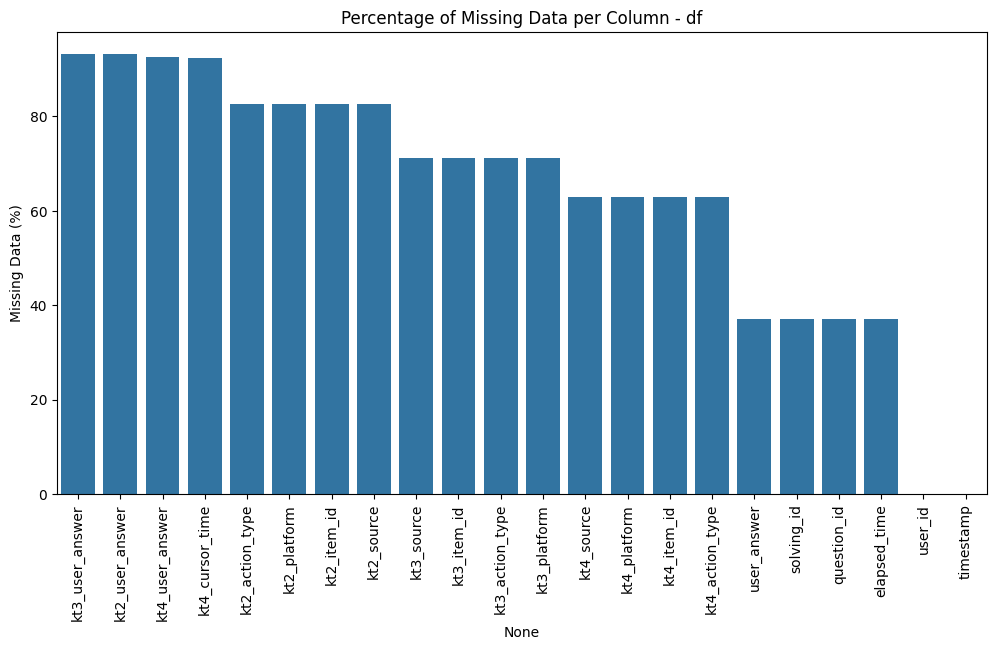

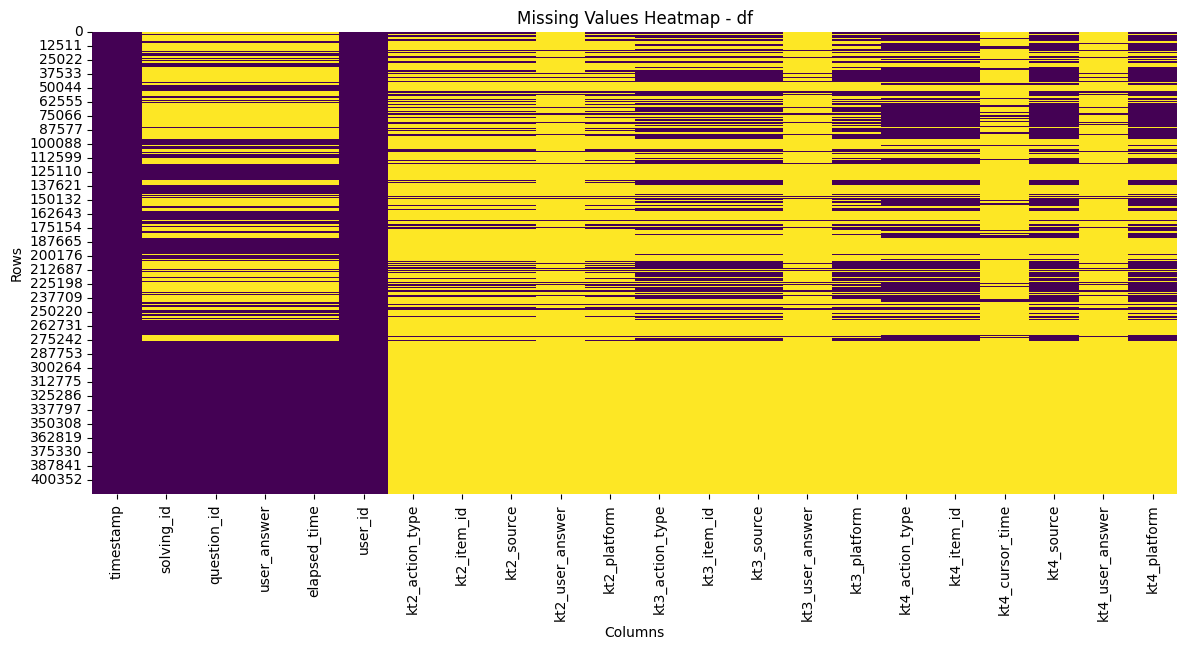

In [9]:
bramlib.analyze_missing_data(df, True)